# Data Visualisation | Exploratory Analysis

2025-07-21 01:53:35.937573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753062816.295271      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753062816.395497      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Number of images in each class:
PIPEVINE SWALLOW: 119 images
ARCIGERA FLOWER MOTH: 140 images
SIXSPOT BURNET MOTH: 100 images
ATLAS MOTH: 129 images
GREY HAIRSTREAK: 123 images
MALACHITE: 103 images
POPINJAY: 121 images
CABBAGE WHITE: 127 images
EASTERN DAPPLE WHITE: 132 images
AFRICAN GIANT SWALLOWTAIL: 107 images
MESTRA: 120 images
BIRD CHERRY ERMINE MOTH: 133 images
COPPER TAIL: 133 images
OLEANDER HAWK MOTH: 132 images
ORANGE OAKLEAF: 125 images
ORANGE TIP: 137 images
SOUTHERN DOGFACE: 119 images
EMPEROR GUM MOTH: 136 images
AMERICAN SNOOT: 105 images
CRIMSON PATCH: 103 images
BROOKES BIRDWING: 165 images
CLEOPATRA: 133 images
MOURNING CLOAK: 187 images
ZEBRA LONG WING: 104 images
BLUE SPOTTED CROW: 123 images
GLITTERING SAPPHIRE: 130 images
GREAT EGGFLY: 105 images
POLYPHEMUS MOTH: 123 images
GOLD BANDED: 104 images
LUNA MOTH: 117 images
PURPLE HAIRSTREAK: 112 images
TROPICAL LEAFWING: 118 images
QUESTION MARK: 110 images
HERCULES MOTH: 137 images
DANAID EGGFLY: 135 images
CHECQUE

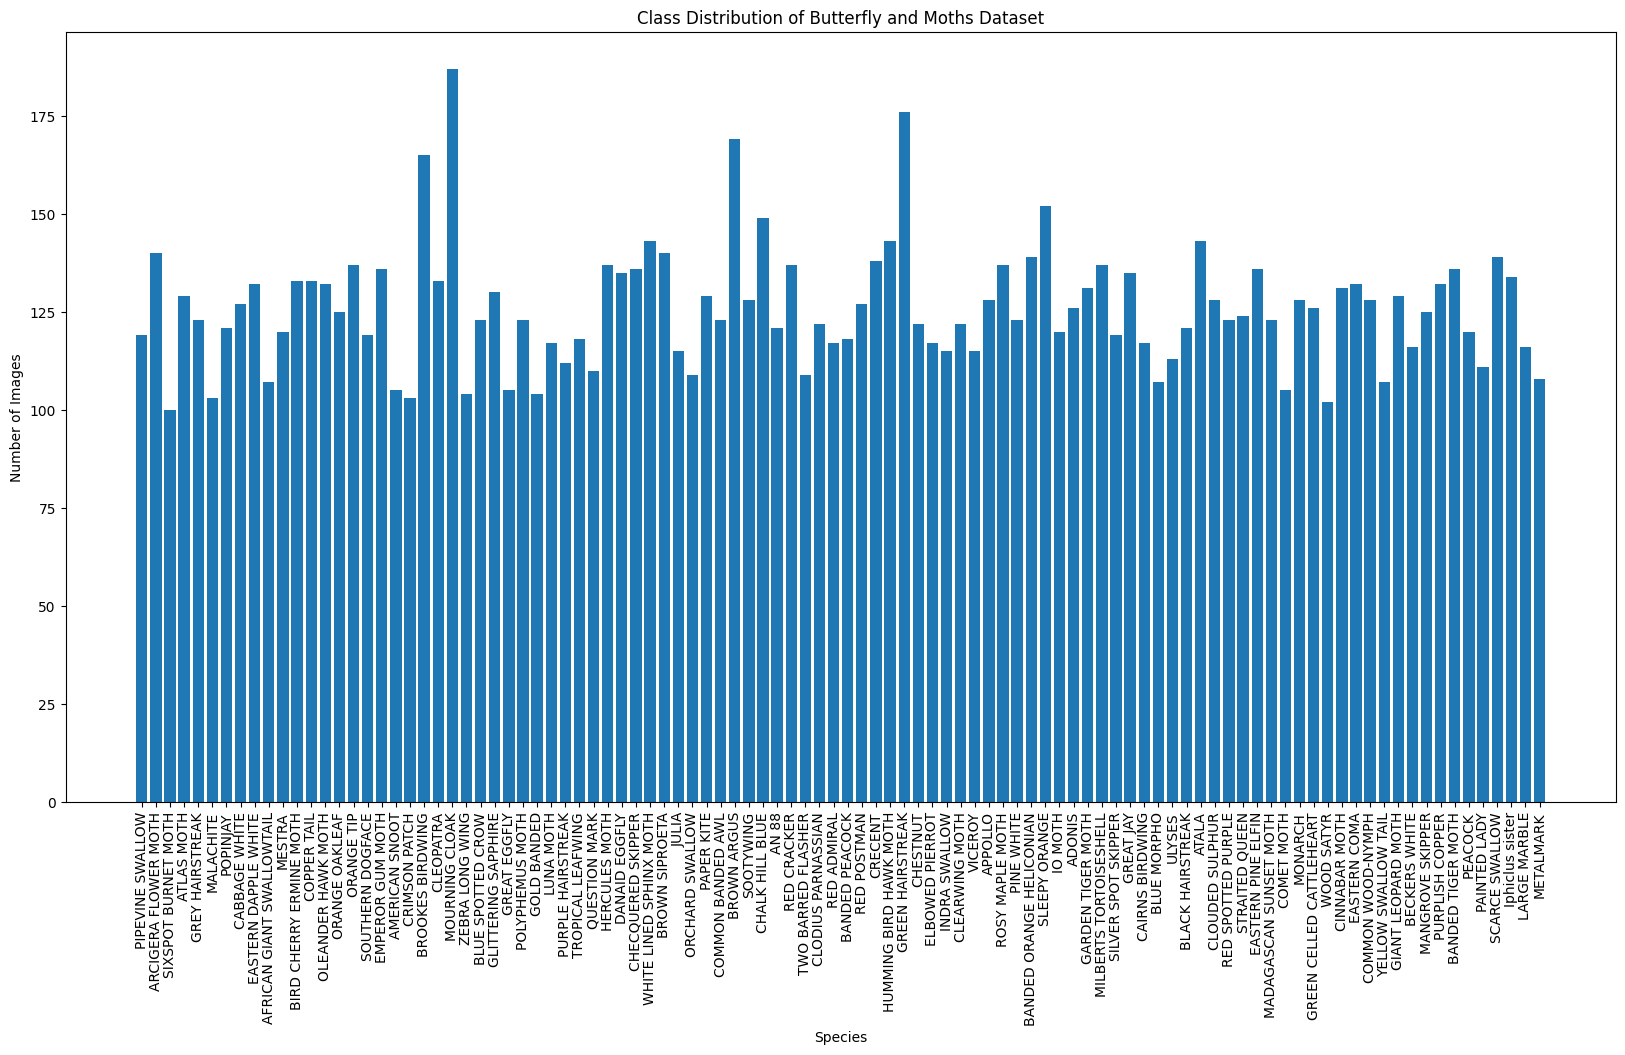

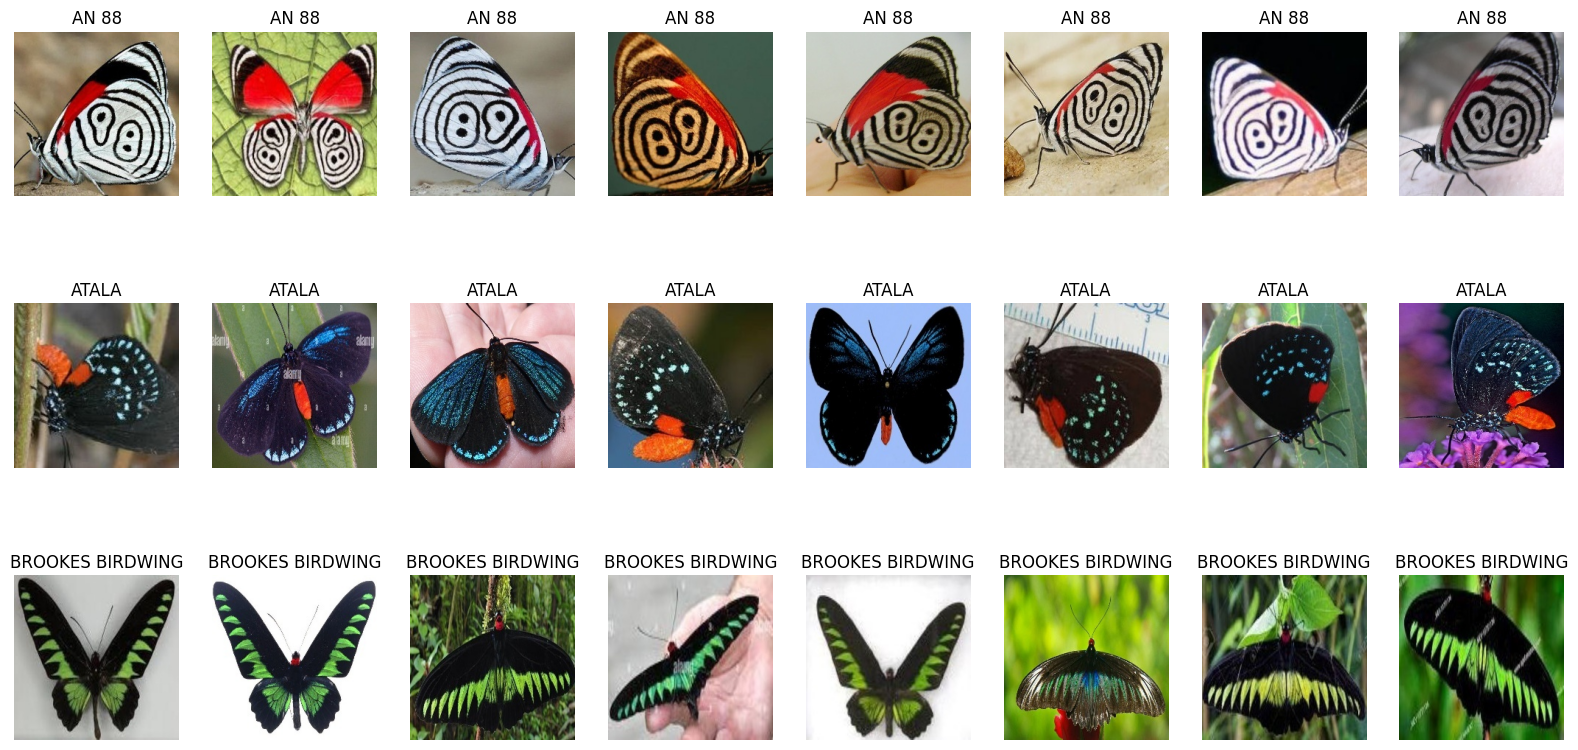

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import tensorflow as tf

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

def load_data(directory, image_size):
    data = []
    labels = []
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path):
            for file in os.listdir(subdir_path):
                file_path = os.path.join(subdir_path, file)
                image = load_img(file_path, target_size=image_size)
                image = img_to_array(image)
                data.append(image)
                labels.append(subdir)
    return np.array(data), np.array(labels)


train_path = '/kaggle/input/butterfly-moth-species-dataset/archive/train'
valid_path = '/kaggle/input/butterfly-moth-species-dataset/archive/valid'
test_path = '/kaggle/input/butterfly-moth-species-dataset/archive/test'


image_size = (224, 224)
X_train, y_train = load_data(train_path, image_size=image_size)
X_valid, y_valid = load_data(valid_path, image_size=image_size)
X_test, y_test = load_data(test_path, image_size=image_size)


class_image_count = {}

for subdir in os.listdir(train_path):
    subdir_path = os.path.join(train_path, subdir)
    if os.path.isdir(subdir_path):
        image_count = len(os.listdir(subdir_path))
        class_image_count[subdir] = image_count

# Print the number of images in each class
print("Number of images in each class:")
for class_name, count in class_image_count.items():
    print(f'{class_name}: {count} images')


min_class = min(class_image_count, key=class_image_count.get)
max_class = max(class_image_count, key=class_image_count.get)

print(f'\nClass with the lowest number of images: {min_class} ({class_image_count[min_class]} images)')
print(f'Class with the highest number of images: {max_class} ({class_image_count[max_class]} images)')

# Plot class distribution
plt.figure(figsize=(20, 10))
plt.bar(class_image_count.keys(), class_image_count.values())
plt.xticks(rotation=90)
plt.xlabel('Species')
plt.ylabel('Number of Images')
plt.title('Class Distribution of Butterfly and Moths Dataset')
plt.show()

# Input parms
classes_to_show = ['AN 88', 'ATALA', 'BROOKES BIRDWING']
images_per_class = 8
rows = len(classes_to_show)
cols = 8

# Filter and sort images
def filter_and_sort_images(X, y, classes, images_per_class):
    filtered_images = []
    filtered_labels = []
    for class_name in classes:
        indices = [i for i, label in enumerate(y) if label == class_name]
        selected_indices = np.random.choice(indices, images_per_class, replace=False)
        for idx in selected_indices:
            filtered_images.append(X[idx])
            filtered_labels.append(y[idx])
    return np.array(filtered_images), np.array(filtered_labels)

# Visualise filtered images
def visualise_images(filtered_images, filtered_labels, rows, cols):
    plt.figure(figsize=(20, 10))
    for i in range(len(filtered_images)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(filtered_images[i].astype("uint8"))
        plt.title(filtered_labels[i])
        plt.axis("off")
    plt.show()

filtered_images, filtered_labels = filter_and_sort_images(X_train, y_train, classes_to_show, images_per_class)
visualise_images(filtered_images, filtered_labels, rows, cols)



# Train Model | Evaluate | Visualise


Found 12594 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
No saved model found, creating a new model


I0000 00:00:1753063412.216171      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1753063412.216867      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1753063443.199648     121 service.cc:148] XLA service 0x7acdec002640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753063443.201483     121 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1753063443.201507     121 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1753063444.454657     121 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1753063451.581534     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3379 - loss: 3.2745
Epoch 1: val_loss improved from inf to 0.47898, saving model to model_checkpoint.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.3403 - loss: 3.2600 - val_accuracy: 0.8620 - val_loss: 0.4790
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8625 - loss: 0.4974
Epoch 2: val_loss improved from 0.47898 to 0.32578, saving model to model_checkpoint.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8626 - loss: 0.4969 - val_accuracy: 0.9080 - val_loss: 0.3258
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9182 - loss: 0.2944
Epoch 3: val_loss improved from 0.32578 to 0.27040, saving model to model_checkpoint.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9182 - loss: 0.2943 - val_accuracy: 0.9260 - val_loss: 0.2704
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9397 - loss: 0.2227
Epoch 4: val_loss improved from 0.27040 to 0.24859, saving mod

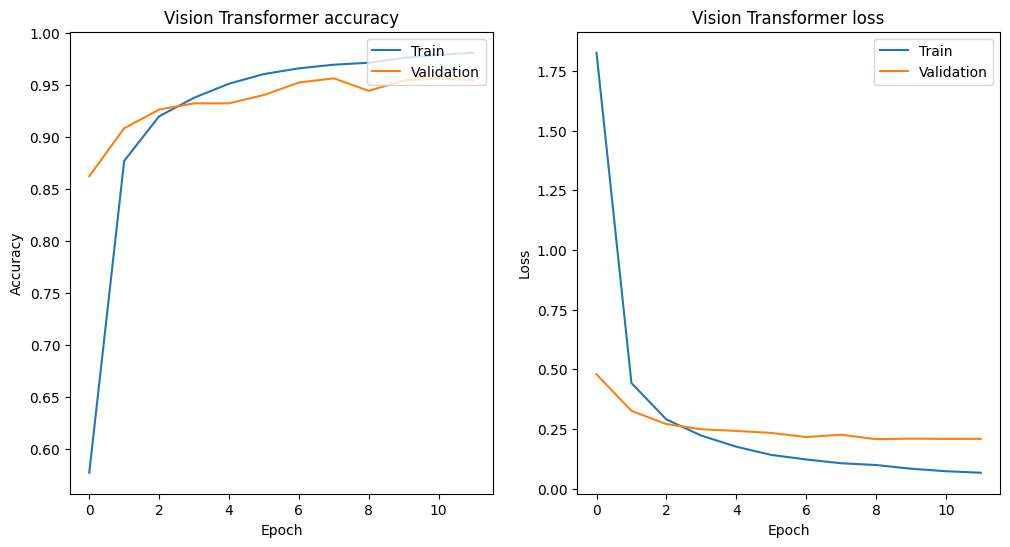

Found 500 images belonging to 100 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
F1 Score: 0.9658387723387724
Accuracy: 0.966
                           precision    recall  f1-score   support

                   ADONIS       0.62      1.00      0.77         5
AFRICAN GIANT SWALLOWTAIL       1.00      1.00      1.00         5
           AMERICAN SNOOT       1.00      0.80      0.89         5
                    AN 88       1.00      1.00      1.00         5
                  APPOLLO       1.00      1.00      1.00         5
     ARCIGERA FLOWER MOTH       1.00      1.00      1.00         5
                    ATALA       1.00      0.80      0.89         5
               ATLAS MOTH       1.00      1.00      1.00         5
 BANDED ORANGE HELICONIAN       1.00      1.00      1.00         5
           BANDED PEACOCK       1.00      1.00      1.00         5
        BANDED TIGER MOTH       1.00      1.00      1.00         5
            BECKERS WHITE       1.00      0.80      0.89         5
  B

In [ ]:
import json
import tensorflow_hub as hub
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Input, Resizing, Lambda
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from sklearn.metrics import classification_report, f1_score, accuracy_score
import time

train_path = '/kaggle/input/butterfly-moth-species-dataset/archive/train'
valid_path = '/kaggle/input/butterfly-moth-species-dataset/archive/valid'
test_path = '/kaggle/input/butterfly-moth-species-dataset/archive/test'

custom_image_size = (224, 224) 
target_image_size = (224, 224)  
batch_size = 128

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(train_path, target_size=custom_image_size, batch_size=batch_size, class_mode='categorical')
valid_generator = datagen.flow_from_directory(valid_path, target_size=custom_image_size, batch_size=batch_size, class_mode='categorical')
test_generator = datagen.flow_from_directory(test_path, target_size=custom_image_size, batch_size=batch_size, class_mode='categorical')

num_classes = train_generator.num_classes

# Define paths for saving
checkpoint_path = 'model_checkpoint.keras'
history_path = 'history.json'

# Save training history after every epoch
class HistorySaver(Callback):
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Save the full history dict after each epoch
        with open(self.filepath, 'w') as f:
            json.dump(self.model.history.history, f)

# Load model if checkpoint exists, else create a new one
if os.path.exists(checkpoint_path):
    print(f"Loading saved model from {checkpoint_path}")
    model = load_model(checkpoint_path)
    # Load previous history too
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history_dict = json.load(f)
    else:
        history_dict = {}
    # Set initial_epoch to the length of history
    initial_epoch = len(history_dict.get('loss', []))
else:
    print("No saved model found, creating a new model")
    hub_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"
    vit_layer = hub.KerasLayer(hub_url, trainable=False)

    inputs = Input(shape=(custom_image_size[0], custom_image_size[1], 3))
    x = Resizing(target_image_size[0], target_image_size[1])(inputs)
    x = Lambda(lambda x: tf.image.convert_image_dtype(x, dtype=tf.float32))(x)
    x = Lambda(lambda x: vit_layer(x))(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs) 

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history_dict = {}
    initial_epoch = 0

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    checkpoint_path,
    save_weights_only=False,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)
history_saver = HistorySaver(history_path)

# Train model continuing from where it left off
start_time = time.time()
history = model.fit(
    train_generator,
    epochs=20,
    initial_epoch=initial_epoch,
    validation_data=valid_generator,
    callbacks=[early_stopping, checkpoint, history_saver],
    verbose=1
)
end_time = time.time()
training_time = end_time - start_time
print(f"Training Time for this run: {training_time} seconds")

# Merge old history with new
for k, v in history.history.items():
    if k in history_dict:
        history_dict[k].extend(v)
    else:
        history_dict[k] = v

# Save the merged history (final update)
with open(history_path, 'w') as f:
    json.dump(history_dict, f)

# Plot combined training history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.title('Vision Transformer accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.title('Vision Transformer loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# Evaluate on test set
valid_generator2 = datagen.flow_from_directory(test_path, target_size=custom_image_size, batch_size=batch_size, class_mode='categorical', shuffle=False)
y_true = valid_generator2.classes
y_pred = np.argmax(model.predict(valid_generator2), axis=1)

f1 = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
print(f"F1 Score: {f1}")
print(f"Accuracy: {accuracy}")
print(classification_report(y_true, y_pred, target_names=list(valid_generator2.class_indices.keys())))

# Save the final model explicitly
model.save('model_final.keras')
